# Continuation of the Practical Workshop: Deep Learning in Oncological Diagnosis
**Course:** Digitalization, AI and XAI — Universidad Panamericana

### Clinical Objective:
Develop a Deep Neural Network (DNN) capable of classifying breast tumors as **Benign** or **Malignant** from morphometric features extracted from digital biopsy images (FNA).

### Workflow (Pipeline):
1. **Ingestion:** Load the *Breast Cancer Wisconsin Dataset*.
2. **Analysis (EDA):** Visualize the clinical distribution.
3. **Preprocessing:** Tensor standardization.
4. **DL Architecture:** Build a multi-layer network with regularization (Dropout).
5. **Clinical Evaluation:** Confusion matrix and classification report.
6. **The Black Box Problem:** Where deep learning hits its operational limit.
7. **Interpretable Baselines:** What transparency actually looks like.
8. **The Central Question of XAI:** Setting up the rest of the course.

In [1]:
# Install all required libraries for the clinical lab
# Note: We use %pip instead of !pip to ensure installation in this specific kernel

%pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

In [2]:
# 1. Import the Data Science Ecosystem
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning and Clinical Metrics
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Ecosystem loaded. TensorFlow version:", tf.__version__)

Ecosystem loaded. TensorFlow version: 2.20.0


## 1. Loading Real Clinical Data
We will use a dataset that is a standard benchmark in biomedical research. It contains 30 continuous variables (such as tumor radius, texture, symmetry) computed from digital cell images obtained through Fine Needle Aspiration (FNA) biopsies.

In [14]:
# Load data
cancer_data = load_breast_cancer()

# Create a DataFrame for tabular manipulation
df = pd.DataFrame(cancer_data['data'], columns=cancer_data['feature_names'])

# Add the target variable (0 = Malignant, 1 = Benign in sklearn's original encoding)
# We invert so that 1 = Malignant (clinical positive) and 0 = Benign
df['Diagnosis'] = 1 - cancer_data['target']

print(f"Cohort dimensions: {df.shape[0]} patients and {df.shape[1]} variables.")
df.head()

Cohort dimensions: 569 patients and 31 variables.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 2. Exploratory Visual Analysis (EDA)
Let's look at how a couple of key variables are distributed. In medicine, finding clear boundaries between diagnoses is the first step — and it tells us how hard the classification problem really is.

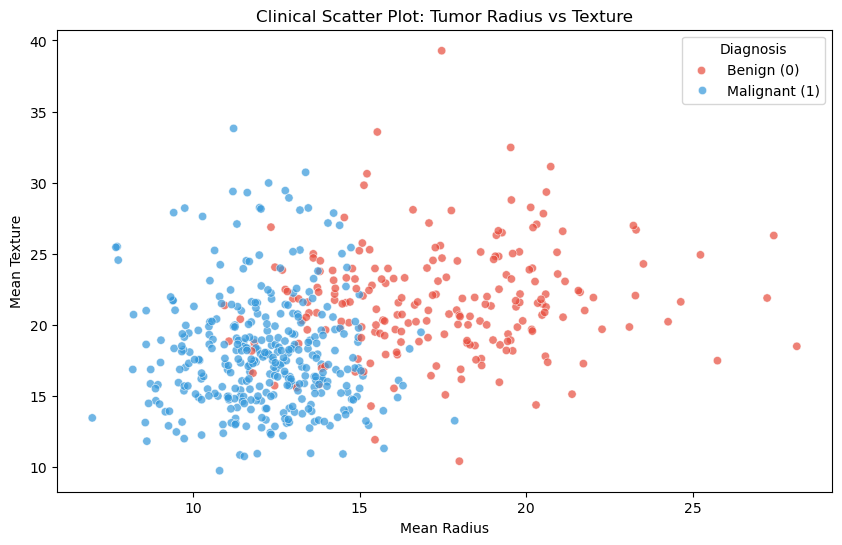

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='mean radius',
    y='mean texture',
    hue='Diagnosis',
    data=df,
    palette=['#3498db', '#e74c3c'],
    alpha=0.7
)
plt.title('Clinical Scatter Plot: Tumor Radius vs Texture')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.legend(title='Diagnosis', labels=['Benign (0)', 'Malignant (1)'])
plt.show()

## 3. Preprocessing: The Gold Standard
Neural Networks are extremely sensitive to mathematical scale. A variable measured in hundreds (e.g., Area) will dominate one measured in decimals (e.g., Symmetry), regardless of clinical relevance.

**We must Standardize (Z-score normalization):** each feature is rescaled to have mean = 0 and standard deviation = 1. This ensures no single variable has an unfair numerical advantage during training.

In [16]:
# Separate features (X) from diagnosis (y)
X = df.drop('Diagnosis', axis=1).values
y = df['Diagnosis'].values

# Split the cohort: 75% Training, 25% Validation
# stratify=y ensures both splits maintain the same class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardization
# IMPORTANT: We fit ONLY on training data, then transform both sets
# Fitting on test data would constitute data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data standardized. Example of the first transformed row (first 5 values):")
print(X_train_scaled[0][:5])

Data standardized. Example of the first transformed row (first 5 values):
[-0.7457497  -0.22189399 -0.76763823 -0.69992463 -0.17745016]


## 4. Deep Neural Network Architecture
We will build a robust model. We include **Dropout**, a technique that randomly "turns off" neurons during training, forcing the network not to rely on any single variable — mimicking the clinical process of seeking a "second opinion" from different evidence.

**Architecture summary:**
- **Input layer:** 30 features
- **Hidden layer 1:** 16 neurons (ReLU) + 20% Dropout
- **Hidden layer 2:** 8 neurons (ReLU) + 20% Dropout
- **Output layer:** 1 neuron (Sigmoid) → outputs a probability between 0% and 100%

In [17]:
model = Sequential()

# Input and First Hidden Layer (30 input features -> 16 neurons)
model.add(Dense(16, activation='relu', input_shape=(30,)))
model.add(Dropout(0.2))  # Randomly disable 20% of neurons to prevent overfitting

# Second Hidden Layer (deeper abstraction)
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

# Output Layer (1 neuron with Sigmoid to emit a probability from 0 to 1)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

### Training with *Early Stopping*
In medicine, over-training a model causes it to **memorize** the training patients rather than learning generalizable rules — this is called **overfitting**.

We use an "emergency brake" (*Early Stopping*): if the model stops improving on the validation set for 10 consecutive epochs, training halts automatically. The learning curve below shows how training loss and validation loss evolve — ideally they should track each other closely.

Epoch 51: early stopping


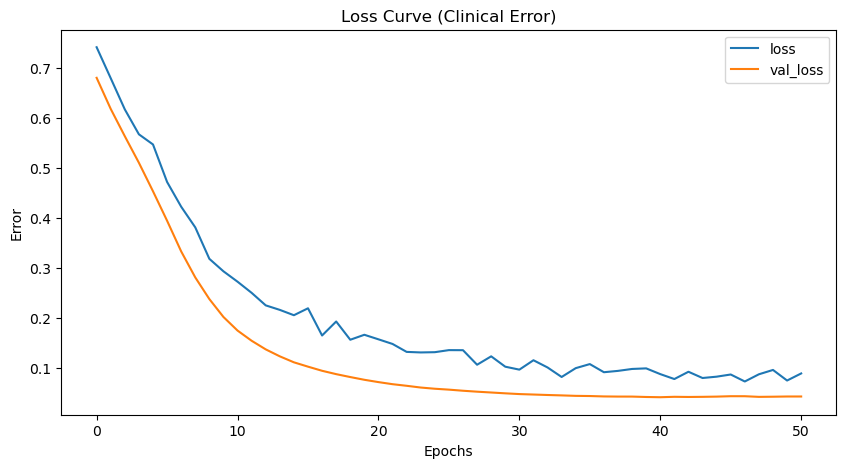

In [18]:
# If the model stops improving on validation data for 10 epochs, stop training.
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

history = model.fit(
    x=X_train_scaled,
    y=y_train,
    epochs=100,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=0  # Hide per-line output to keep the notebook clean
)

# Visualize the Learning Curve
loss_df = pd.DataFrame(history.history)
loss_df[['loss', 'val_loss']].plot(figsize=(10, 5), title='Loss Curve (Clinical Error)')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

## 5. Clinical Evaluation
Overall accuracy is not enough. In oncology, a **False Negative** (telling a sick patient they are healthy) can be fatal. We analyze the **Confusion Matrix** and the full classification report.

**Key metrics to understand:**

1. **Precision** — When the model says "Malignant", how often is it right?
   $$\text{Precision} = \frac{TP}{TP + FP}$$

2. **Recall (Sensitivity)** — Of all actual malignant tumors, how many did the model catch?
   $$\text{Recall} = \frac{TP}{TP + FN}$$
   > ⚠️ In clinical settings, **Recall is the most critical metric** — missing a cancer is far more dangerous than a false alarm.

3. **F1-Score** — Harmonic mean of Precision and Recall. Useful when classes are imbalanced.
   $$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

4. **Support** — The actual number of samples of each class in the test set.

5. **Macro Avg** — Simple average across classes (treats both equally).

6. **Weighted Avg** — Average weighted by support (more frequent classes have more influence).

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 


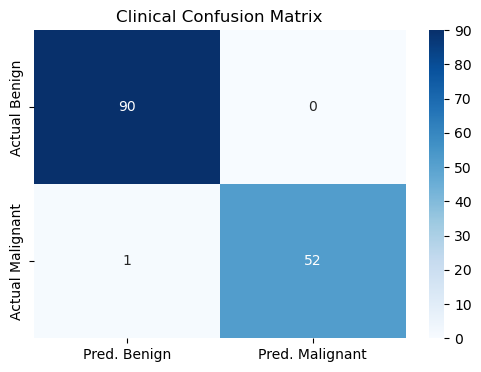


Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.99      1.00      0.99        90
Malignant (1)       1.00      0.98      0.99        53

     accuracy                           0.99       143
    macro avg       0.99      0.99      0.99       143
 weighted avg       0.99      0.99      0.99       143



In [19]:
# Generate predictions (probabilities → binary labels at 50% threshold)
probabilities = model.predict(X_test_scaled)
binary_predictions = (probabilities > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, binary_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred. Benign', 'Pred. Malignant'],
    yticklabels=['Actual Benign', 'Actual Malignant']
)
plt.title('Clinical Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, binary_predictions, target_names=['Benign (0)', 'Malignant (1)']))

## 6. The Operational Limit: The Black Box

The model achieves impressive accuracy (typically > 95%). But accuracy alone is not enough for clinical deployment. Let's expose the fundamental problem.

Below we find **patients where the model is highly confident** — more than 95% certain in its prediction. This is exactly when the lack of explanation becomes most dangerous.

In [20]:
print("=" * 60)
print("HIGH-CONFIDENCE PREDICTIONS — WITH ZERO EXPLANATION")
print("=" * 60)

count = 0
for i in range(len(X_test_scaled)):
    prob = model.predict(X_test_scaled[i].reshape(1, -1), verbose=0)[0][0]
    if prob > 0.95 or prob < 0.05:  # Model is very confident
        actual = y_test[i]
        prediction = 'MALIGNANT' if prob > 0.5 else 'BENIGN'
        confidence = prob * 100 if prob > 0.5 else (1 - prob) * 100
        correct = 'CORRECT' if (prob > 0.5) == actual else 'INCORRECT!'

        print(f"\nPatient #{i}  {correct}")
        print(f"  AI says:  {prediction} ({confidence:.1f}% confidence)")
        print(f"  Reality:  {'Malignant' if actual == 1 else 'Benign'}")
        print(f"  Why? The model cannot tell us.")

        count += 1
        if count >= 5:
            break

print("\n" + "=" * 60)
print("CRITICAL QUESTION FOR THE MEDICAL COMMITTEE:")
print("Which of the 30 variables (radius, texture, symmetry...)")
print("drove the AI to these conclusions?")
print("The Keras model CANNOT tell us directly.")
print("Its decisions are trapped inside millions of numerical weights.")
print("=" * 60)

HIGH-CONFIDENCE PREDICTIONS — WITH ZERO EXPLANATION

Patient #0  CORRECT
  AI says:  MALIGNANT (100.0% confidence)
  Reality:  Malignant
  Why? The model cannot tell us.

Patient #1  CORRECT
  AI says:  BENIGN (99.6% confidence)
  Reality:  Benign
  Why? The model cannot tell us.

Patient #2  CORRECT
  AI says:  MALIGNANT (100.0% confidence)
  Reality:  Malignant
  Why? The model cannot tell us.

Patient #3  CORRECT
  AI says:  BENIGN (100.0% confidence)
  Reality:  Benign
  Why? The model cannot tell us.

Patient #4  CORRECT
  AI says:  BENIGN (97.0% confidence)
  Reality:  Benign
  Why? The model cannot tell us.

CRITICAL QUESTION FOR THE MEDICAL COMMITTEE:
Which of the 30 variables (radius, texture, symmetry...)
drove the AI to these conclusions?
The Keras model CANNOT tell us directly.
Its decisions are trapped inside millions of numerical weights.


## 7. What Interpretability Actually Looks Like

Before we can appreciate *why* XAI matters, we need to see what **a truly interpretable model** looks like. We train two classical models on the same data and compare.

The key question we are building toward: **when the simpler, transparent model performs almost as well, what justifies using the black box?**

### 7.1 Logistic Regression — Fully Interpretable

Logistic Regression is a linear model where each feature gets a **single coefficient** that represents its contribution to the prediction. Every coefficient is visible, auditable, and has a clear directional meaning:
- **Positive coefficient** → feature pushes toward Malignant
- **Negative coefficient** → feature pushes toward Benign
- **Larger magnitude** → stronger influence

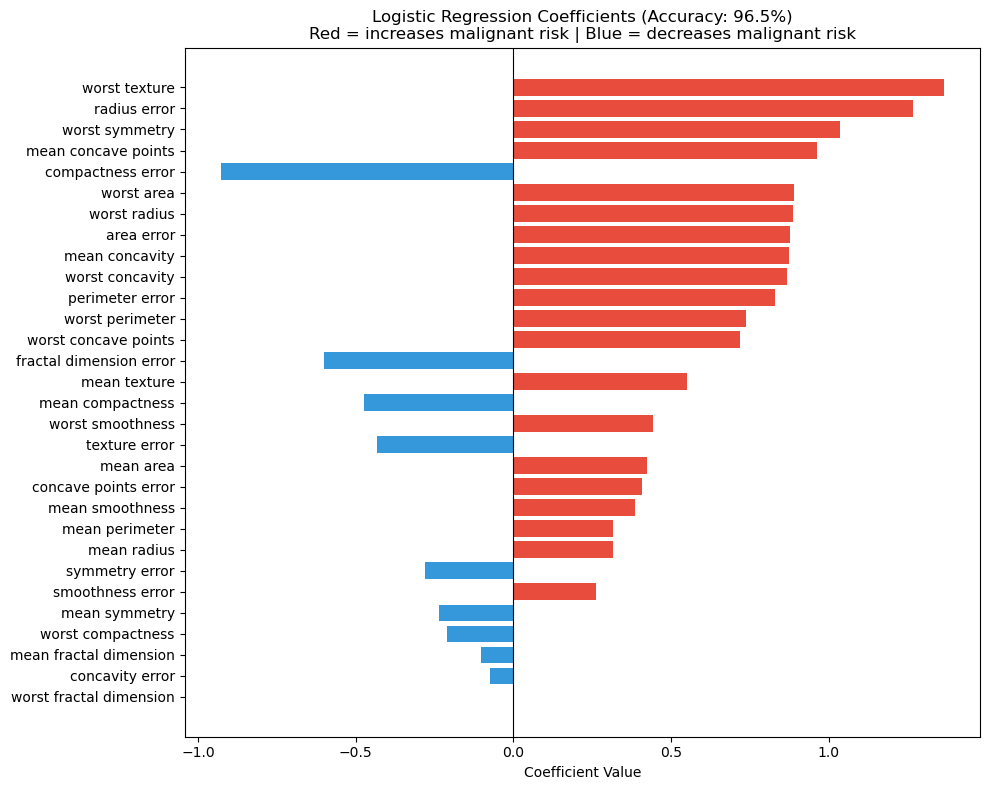

Top 5 most influential features:
                Feature  Coefficient
21        worst texture     1.365780
10         radius error     1.267201
28       worst symmetry     1.036496
7   mean concave points     0.963006
15    compactness error    -0.927483


In [22]:
# Train Logistic Regression on the same scaled data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_acc = lr.score(X_test_scaled, y_test)

# Visualize the coefficients — this IS the explanation
coef_df = pd.DataFrame({
    'Feature': cancer_data.feature_names,
    'Coefficient': lr.coef_[0]
})
coef_df_sorted = coef_df.reindex(
    coef_df['Coefficient'].abs().sort_values(ascending=True).index
)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in coef_df_sorted['Coefficient']]
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(
    f'Logistic Regression Coefficients (Accuracy: {lr_acc:.1%})\n'
    'Red = increases malignant risk | Blue = decreases malignant risk'
)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("Top 5 most influential features:")
print(coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head())

### 7.2 Decision Tree — Every Decision is Auditable

A Decision Tree makes predictions through a sequence of **explicit, human-readable rules**: *"If the worst concave points > 0.14, go left; otherwise go right."* A clinician can trace any individual prediction step by step — no black box.

We limit the depth to 3 levels for readability. In practice, deeper trees capture more complexity but become harder to audit.

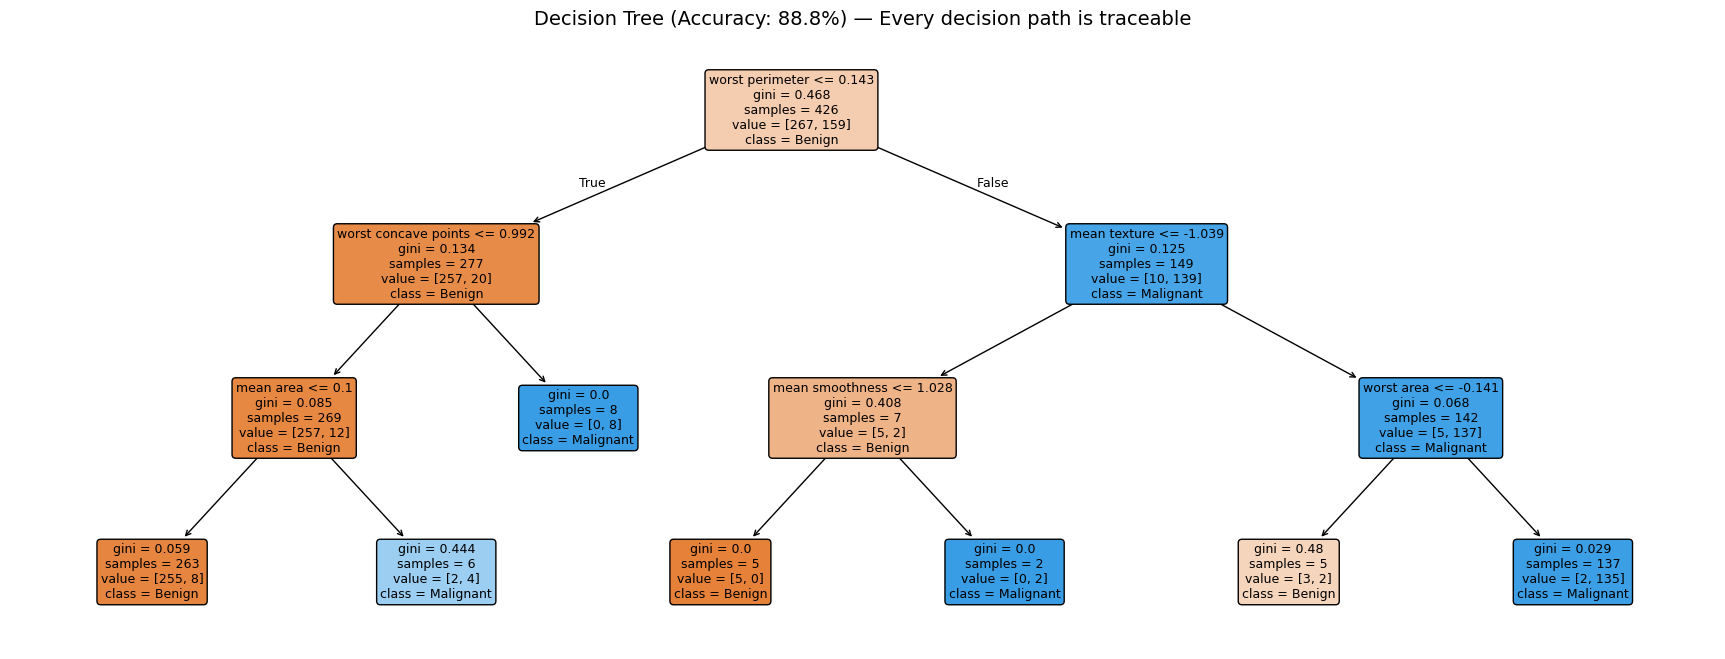

In [23]:
# Train a shallow Decision Tree
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train_scaled, y_train)
tree_acc = tree.score(X_test_scaled, y_test)

# Visualize the full decision logic
plt.figure(figsize=(22, 8))
plot_tree(
    tree,
    feature_names=cancer_data.feature_names,
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(
    f'Decision Tree (Accuracy: {tree_acc:.1%}) — Every decision path is traceable',
    fontsize=14
)
plt.show()

## 8. The Central Tension: Performance vs. Interpretability

Now we can put all three models side by side and confront the fundamental trade-off that drives the entire field of Explainable AI.

In [24]:
dnn_acc = (binary_predictions.flatten() == y_test).mean()

print("MODEL COMPARISON")
print("=" * 60)
print(f"  Deep Neural Network:    {dnn_acc:.1%}  accuracy  |  NOT GOOD: Black Box")
print(f"  Logistic Regression:    {lr_acc:.1%}  accuracy  |  GOOD! Fully Interpretable")
print(f"  Decision Tree (d=3):    {tree_acc:.1%}  accuracy  |  GOOD! Fully Interpretable")
print("=" * 60)
print()
print("Performance gap (DNN vs Logistic Regression):")
print(f"  {(dnn_acc - lr_acc)*100:.1f} percentage points")
print()
print("DISCUSSION QUESTIONS:")
print("  1. Is a ~3% accuracy gain worth losing full interpretability?")
print("  2. Who should make that decision — the data scientist or the clinician?")
print("  3. What would a hospital regulator require before approving the DNN?")
print("  4. What if the DNN makes an error — how do we investigate why?")

MODEL COMPARISON
  Deep Neural Network:    99.3%  accuracy  |  NOT GOOD: Black Box
  Logistic Regression:    96.5%  accuracy  |  GOOD! Fully Interpretable
  Decision Tree (d=3):    88.8%  accuracy  |  GOOD! Fully Interpretable

Performance gap (DNN vs Logistic Regression):
  2.8 percentage points

DISCUSSION QUESTIONS:
  1. Is a ~3% accuracy gain worth losing full interpretability?
  2. Who should make that decision — the data scientist or the clinician?
  3. What would a hospital regulator require before approving the DNN?
  4. What if the DNN makes an error — how do we investigate why?


## 9. The Open Question — Setting Up the Course

We now have a precise, concrete problem:

---

> **The neural network is our most powerful model, but it cannot explain its own decisions.**
> The interpretable models can explain themselves, but sacrifice some performance.
> **In clinical settings, both accuracy and explainability are non-negotiable.**

---

This tension is not unique to medicine. It appears in:
- **Finance:** Why was a loan rejected?
- **Criminal justice:** Why did an algorithm flag a suspect?
- **Hiring:** Why was a resume screened out?
- **Autonomous vehicles:** Why did the car brake?

### Good news that we will work on different XAI techniques such as:

| Technique | What it does | When to use it |
|-----------|-------------|----------------|
| **LIME** | Explains individual predictions locally with a simple surrogate model | Quick, intuitive local explanations |
| **SHAP** | Assigns each feature a fair contribution score using game theory | Rigorous global and local explanations |
| **Attention Maps** | Shows which parts of an image/text the model focused on | Vision and NLP tasks |
| **Counterfactuals** | "What would need to change for a different outcome?" | Actionable explanations |

### The guiding question for every future session:

**"Can we give a clinician — or a regulator, or a patient — a satisfying answer to the question: *why did the AI decide this?*"**

---

### Appendix — Interactive Playground
Explore neural network decision boundaries visually:  
👉 https://playground.tensorflow.org/